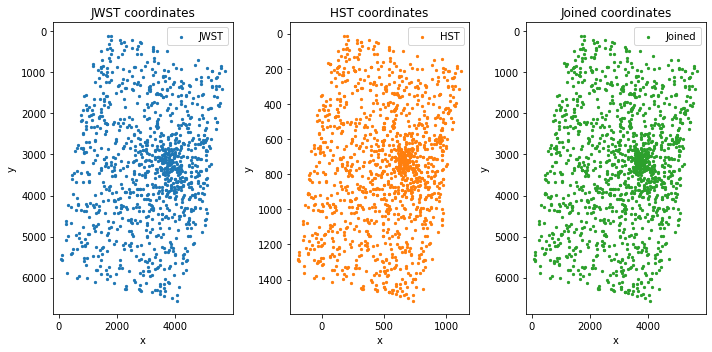

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# File paths
jwst_file = "/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/winstonlist.dat"
hst_file  = "/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/HST_phot.dat"
joined_file = "/scratch/wyz5rge/synthetic-hr/notebooks/2025/08-11_morten-chi-squared-cross-reference/phot_joined.dat"

# Load JWST data (x, y are first two columns)
jwst = np.loadtxt(jwst_file, usecols=(0,1))
jwst_x, jwst_y = jwst[:,0], jwst[:,1]

# Load HST data (x, y are first two columns)
hst = np.loadtxt(hst_file, usecols=(0,1))
hst_x, hst_y = hst[:,0], hst[:,1]

# Load joined data
joined = np.loadtxt(joined_file)
joined_x, joined_y = joined[:,0], joined[:,1]

# Plot side by side
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.scatter(jwst_x, jwst_y, s=5, c="tab:blue", label="JWST")
plt.gca().invert_yaxis()  # common in astro images
plt.title("JWST coordinates")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,3,2)
plt.scatter(hst_x, hst_y, s=5, c="tab:orange", label="HST")
plt.gca().invert_yaxis()
plt.title("HST coordinates")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,3,3)
plt.scatter(joined_x, joined_y, s=5, c="tab:green", label="Joined")
plt.gca().invert_yaxis()
plt.title("Joined coordinates")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.tight_layout()
plt.show()

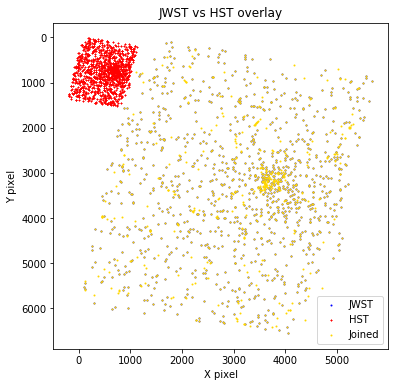

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(jwst_x, jwst_y, s=1, c="blue", label="JWST")
plt.scatter(hst_x, hst_y, s=1, c="red", marker="x", label="HST")
plt.scatter(joined_x, joined_y, s=1, c="gold", label="Joined")
plt.gca().invert_yaxis()
plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("JWST vs HST overlay")
plt.legend()
plt.show()

Total joined rows: 1389
Kept after masking: 1010
Excluded: 379


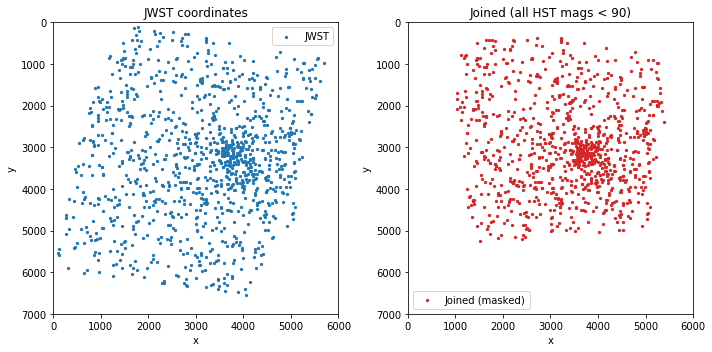

In [26]:
# Extract HST magnitude columns (f125, f139, f160)
hst_mags = joined[:, [8, 10, 12]]

# Build mask: keep rows where all HST magnitudes are < 90
mask = np.all(hst_mags < 90, axis=1)

masked_x, masked_y = joined[:,0][mask], joined[:,1][mask]

print(f"Total joined rows: {len(joined)}")
print(f"Kept after masking: {np.sum(mask)}")
print(f"Excluded: {len(joined) - np.sum(mask)}")

# Plot JWST vs masked joined
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(jwst_x, jwst_y, s=5, c="tab:blue", label="JWST")
plt.xlim(0, 6000)
plt.ylim(0, 7000)
plt.gca().invert_yaxis()
plt.title("JWST coordinates")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(masked_x, masked_y, s=5, c="tab:red", label="Joined (masked)")
plt.xlim(0, 6000)
plt.ylim(0, 7000)
plt.gca().invert_yaxis()
plt.title("Joined (all HST mags < 90)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.tight_layout()
plt.show()

Saved 1010 kept coordinates to kept_coords.dat
Matched 815 JWST rows to kept joined rows


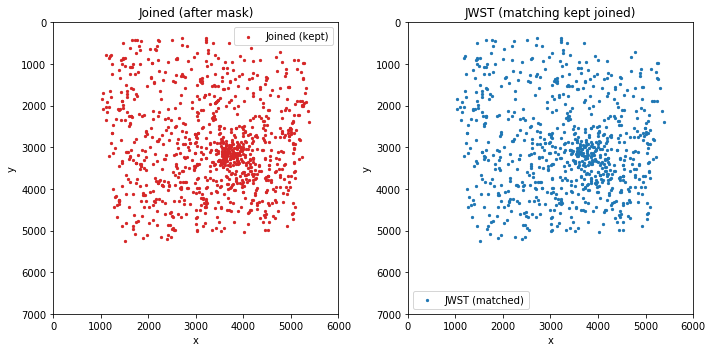

In [28]:
# Get kept coordinates (x,y) from joined file
kept_coords = joined[mask, 0:2]

# Save to file
np.savetxt("kept_coords.dat", kept_coords, fmt="%.6f")

print(f"Saved {len(kept_coords)} kept coordinates to kept_coords.dat")

# --- Match with JWST file ---
# Build a set of tuples for fast lookup
kept_set = set(map(tuple, np.round(kept_coords, 6)))

# Load full JWST file (all columns)
jwst_full = np.loadtxt(jwst_file)

# JWST coords
jwst_coords = jwst_full[:, 0:2]

# Mask JWST rows whose (x,y) are in kept_set
jwst_mask = np.array([tuple(np.round(row, 6)) in kept_set for row in jwst_coords])
jwst_matched = jwst_coords[jwst_mask]

print(f"Matched {len(jwst_matched)} JWST rows to kept joined rows")

# --- Plot ---
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(masked_x, masked_y, s=5, c="tab:red", label="Joined (kept)")
plt.xlim(0, 6000)
plt.ylim(0, 7000)
plt.gca().invert_yaxis()
plt.title("Joined (after mask)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(jwst_matched[:,0], jwst_matched[:,1], s=5, c="tab:blue", label="JWST (matched)")
plt.xlim(0, 6000)
plt.ylim(0, 7000)
plt.gca().invert_yaxis()
plt.title("JWST (matching kept joined)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.tight_layout()
plt.show()